# Wind turbine control: MPPT below rated, blade-pitch regulation above rated

A variable-speed wind turbine has two jobs, set by the wind speed. **Below rated
wind**, it should harvest as much energy as possible — track the aerodynamically
optimal rotor speed (maximum-power-point tracking, MPPT). **Above rated wind**,
there is more power available than the drivetrain and generator can take, so it
must *shed* the excess and hold rated power — done by feathering the blades
(pitch control). This notebook builds a ~1.75 MW turbine in Jaxonomy from
primitive `LeafSystem` blocks and shows both regimes working, each checked
against an analytic target.

## Prerequisites
- Jaxonomy basics: `LeafSystem`, `declare_continuous_state`, `DiagramBuilder`,
  `simulate` (see the quickstart / `lqr.ipynb`).
- The `npa` vs `jnp` convention: inside block callbacks we use
  `jaxonomy.backend.numpy_api as npa` so the block is backend-neutral.

## What we model — and what we leave out
A three-element causal model: aerodynamics (a $C_p(\lambda,\beta)$ power
coefficient), a **two-mass torsional drivetrain** (rotor + generator coupled by a
flexible shaft and a gearbox), and a controller (MPPT torque + PI pitch).

> **Out of scope, on purpose.** The doubly-fed induction generator's electrical
> dynamics (stator/rotor flux, converter switching, grid synchronisation) are
> collapsed into an ideal commanded generator torque. We model the
> *mechanical-to-electrical power-capture control*, not the power electronics.


## 1. A self-consistent turbine

The parameters below are chosen to be mutually consistent: the gearbox ratio, rated generator speed, and the optimal tip-speed ratio together fix the rated wind speed and rated power. We compute the optimal tip-speed ratio $\lambda_{opt}$ and peak power coefficient $C_{p,max}$ numerically from the $C_p$ surface rather than hard-coding them.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jaxonomy import LeafSystem, simulate, SimulatorOptions, DiagramBuilder
from jaxonomy.library import SourceBlock
from jaxonomy.backend import numpy_api as npa

# Standard Heier Cp(lambda, beta) performance coefficient (beta in degrees)
def cp_np(lam, beta=0.0):
    li = 1.0 / (lam + 0.08 * beta) - 0.035 / (beta**3 + 1.0)
    return np.maximum(0.0, 0.5176 * (116.0 * li - 0.4 * beta - 5.0) * np.exp(-21.0 * li) + 0.0068 * lam)

lams = np.linspace(2, 14, 8000)
LAMBDA_OPT = float(lams[np.argmax(cp_np(lams))])
CP_MAX = float(cp_np(lams).max())

R, RHO, N_GEAR = 40.0, 1.225, 70.0          # blade radius [m], air density, gearbox ratio
OMEGA_G_RATED = 150.0                        # rated generator speed [rad/s] (~1432 rpm)
OMEGA_R_RATED = OMEGA_G_RATED / N_GEAR
V_RATED = OMEGA_R_RATED * R / LAMBDA_OPT      # wind where the optimal curve reaches rated rotor speed
P_RATED = 0.5 * RHO * np.pi * R**2 * CP_MAX * V_RATED**3
# MPPT optimal-torque law (generator side):  T_e = K_OPT * omega_g^2
K_OPT = (0.5 * RHO * np.pi * R**5 * CP_MAX / LAMBDA_OPT**3) / N_GEAR**3
T_E_RATED = P_RATED / OMEGA_G_RATED

J_R, J_G = 3.0e6, 500.0                       # rotor / generator inertia [kg m^2]
K_SHAFT, D_SHAFT = 2.0e6, 1.0e5              # shaft stiffness / damping
KP_PITCH, KI_PITCH = 0.5, 0.25              # pitch PI gains [deg per rad/s, per rad]

print(f"lambda_opt = {LAMBDA_OPT:.3f},  Cp_max = {CP_MAX:.4f}")
print(f"rated: omega_r = {OMEGA_R_RATED:.2f} rad/s ({OMEGA_R_RATED*30/np.pi:.1f} rpm), "
      f"v_rated = {V_RATED:.2f} m/s, P_rated = {P_RATED/1e6:.2f} MW")
print(f"MPPT gain K_OPT = {K_OPT:.4f} N.m/(rad/s)^2,  rated torque = {T_E_RATED:.0f} N.m")

lambda_opt = 8.100,  Cp_max = 0.4800
rated: omega_r = 2.14 rad/s (20.5 rpm), v_rated = 10.58 m/s, P_rated = 1.75 MW
MPPT gain K_OPT = 0.5189 N.m/(rad/s)^2,  rated torque = 11676 N.m


## 2. Aerodynamics: the $C_p(\lambda,\beta)$ surface

The captured power is $P = \tfrac12\rho\,\pi R^2\,C_p(\lambda,\beta)\,v^3$, where the
tip-speed ratio $\lambda = \omega_r R / v$ and $\beta$ is the blade pitch (deg).
The aerodynamic torque on the low-speed shaft is $T_{aero}=P/\omega_r$. Two facts
drive the whole control design and are visible in the plot below:

1. At $\beta=0$ there is a single optimal $\lambda_{opt}$ where $C_p$ peaks — MPPT
   exists to sit there.
2. Increasing $\beta$ collapses $C_p$ — that is the knob pitch control uses to
   shed power above rated.

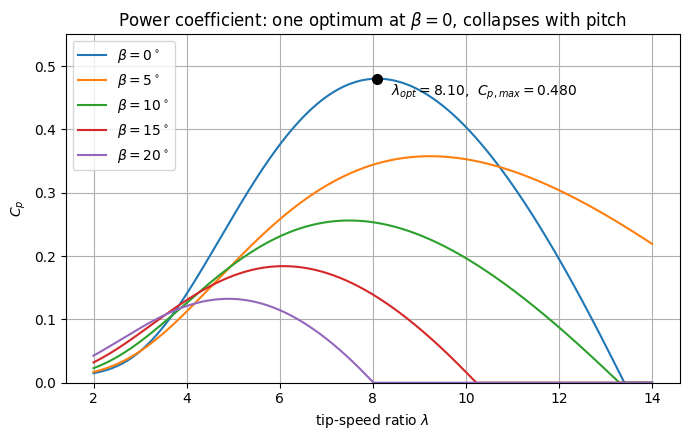

In [2]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for beta in [0, 5, 10, 15, 20]:
    ax.plot(lams, cp_np(lams, beta), label=f"$\\beta={beta}^\\circ$")
ax.plot(LAMBDA_OPT, CP_MAX, "ko", ms=7, zorder=5)
ax.annotate(f"$\\lambda_{{opt}}={LAMBDA_OPT:.2f}$,  $C_{{p,max}}={CP_MAX:.3f}$",
            (LAMBDA_OPT, CP_MAX), textcoords="offset points", xytext=(10, -12))
ax.set_xlabel("tip-speed ratio $\\lambda$"); ax.set_ylabel("$C_p$")
ax.set_title("Power coefficient: one optimum at $\\beta=0$, collapses with pitch")
ax.legend(); ax.grid(True); ax.set_ylim(0, 0.55)
plt.tight_layout(); plt.show()

## 3. The blocks

Three `LeafSystem`s: aerodynamics (feedthrough), the two-mass drivetrain (three continuous states $[\omega_r,\theta_{tw},\omega_g]$), and the controller (one integrator state for the pitch PI). A tiny router exposes the rotor and generator speeds as separate signals.

In [3]:
class Aerodynamics(LeafSystem):
    '''P = 0.5 rho pi R^2 Cp(lambda, beta) v^3;  T_aero = P / omega_r.'''
    def __init__(self):
        super().__init__()
        for nm in ("v_w", "omega_r", "beta"):
            self.declare_input_port(name=nm)
        self.declare_output_port(self.calc, name="T_aero")
    def calc(self, time, state, v_w, omega_r, beta, **kw):
        v = npa.maximum(v_w[0], 0.1); wr = npa.maximum(omega_r[0], 1e-3); b = beta[0]
        lam = wr * R / v
        li = 1.0 / (lam + 0.08 * b) - 0.035 / (b**3 + 1.0)
        cp = npa.clip(0.5176 * (116.0 * li - 0.4 * b - 5.0) * npa.exp(-21.0 * li) + 0.0068 * lam, 0.0, 0.55)
        return npa.array([0.5 * RHO * npa.pi * R**2 * cp * v**3 / wr])


class Drivetrain(LeafSystem):
    '''Two-mass torsional drivetrain. States [omega_r, theta_tw, omega_g].'''
    def __init__(self, omega_r0):
        super().__init__()
        self.declare_continuous_state(
            default_value=npa.array([omega_r0, 0.0, omega_r0 * N_GEAR]), ode=self.ode)
        self.declare_input_port(name="T_aero"); self.declare_input_port(name="T_e")
        self.declare_continuous_state_output(name="states")
    def ode(self, time, state, T_aero, T_e, **kw):
        wr, tw, wg = state.continuous_state
        wg_lss = wg / N_GEAR
        T_shaft = K_SHAFT * tw + D_SHAFT * (wr - wg_lss)
        return npa.array([(T_aero[0] - T_shaft) / J_R,
                          wr - wg_lss,
                          (T_shaft / N_GEAR - T_e[0]) / J_G])


class Controller(LeafSystem):
    '''Region 2: MPPT torque T_e = K_OPT omega_g^2, capped at rated.
    Region 3: hold rated torque; PI pitch on generator-speed error regulates speed.'''
    def __init__(self):
        super().__init__()
        self.declare_continuous_state(default_value=npa.array([0.0]), ode=self.ode)
        self.declare_input_port(name="omega_g")
        self.declare_output_port(self.calc_Te, name="T_e")
        self.declare_output_port(self.calc_beta, name="beta")
    def ode(self, time, state, omega_g, **kw):
        e = omega_g[0] - OMEGA_G_RATED
        beta_u = KP_PITCH * e + KI_PITCH * state.continuous_state[0]
        froze = ((beta_u >= 25.0) & (e > 0)) | ((beta_u <= 0.0) & (e < 0))  # anti-windup
        return npa.array([npa.where(froze, 0.0, e)])
    def calc_Te(self, time, state, omega_g, **kw):
        return npa.array([npa.minimum(K_OPT * omega_g[0]**2, T_E_RATED)])
    def calc_beta(self, time, state, omega_g, **kw):
        e = omega_g[0] - OMEGA_G_RATED
        return npa.array([npa.clip(KP_PITCH * e + KI_PITCH * state.continuous_state[0], 0.0, 25.0)])


class Router(LeafSystem):
    def __init__(self):
        super().__init__(); self.declare_input_port("states")
        self.declare_output_port(lambda t, s, st, **k: npa.array([st[0]]), name="omega_r")
        self.declare_output_port(lambda t, s, st, **k: npa.array([st[2]]), name="omega_g")


## 4. Closed-loop diagram and the two operating regimes

We wire the loop once and run it under two steady winds. **Region 2 (8 m/s):** start at the optimal operating point and let MPPT hold it. **Region 3 (16 m/s):** start at rated rotor speed and let pitch regulate the overspeed. Because the rotor inertia is enormous (3e6 kg·m²) these loops are slow — minutes, not seconds — so we run each long enough to settle and size `buffer_length` so the **full** trajectory is recorded (the adaptive recorder keeps one sample per minor step and silently truncates to the tail if the ring buffer fills).

In [4]:
def run(v_const, omega_r0, t_end):
    b = DiagramBuilder()
    wind = b.add(SourceBlock(lambda t: jnp.array([v_const]), name="wind"))
    aero = b.add(Aerodynamics()); dt = b.add(Drivetrain(omega_r0))
    ctl = b.add(Controller()); rt = b.add(Router())
    b.connect(dt.output_ports[0], rt.input_ports[0])
    b.connect(wind.output_ports[0], aero.input_ports[0])
    b.connect(rt.output_ports[0], aero.input_ports[1])
    b.connect(ctl.output_ports[1], aero.input_ports[2])
    b.connect(aero.output_ports[0], dt.input_ports[0])
    b.connect(ctl.output_ports[0], dt.input_ports[1])
    b.connect(rt.output_ports[1], ctl.input_ports[0])
    for p, nm in [(wind.output_ports[0], "v_w"), (dt.output_ports[0], "states"),
                  (ctl.output_ports[0], "T_e"), (ctl.output_ports[1], "beta")]:
        b.export_output(p, nm)
    diag = b.build()
    return simulate(diag, diag.create_context(), t_span=(0.0, t_end),
                    options=SimulatorOptions(max_minor_step_size=0.1, buffer_length=40000),
                    recorded_signals={k: diag.get_output_port(k)
                                      for k in ("v_w", "states", "T_e", "beta")})

res2 = run(8.0, LAMBDA_OPT * 8.0 / R, 400.0)     # region 2: start on the optimum
res3 = run(16.0, OMEGA_R_RATED, 800.0)           # region 3: start at rated rotor speed
print(f"region 2: {len(res2.time)} samples to {res2.time[-1]:.0f}s; "
      f"region 3: {len(res3.time)} samples to {res3.time[-1]:.0f}s")

21:58:32.396 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


21:58:32.397 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=0.1, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=4, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 5 nodes), rtol=1e-06, atol=1e-08, max_step_size=0.1, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


21:58:32.594 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


21:58:32.595 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=0.1, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=4, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 5 nodes), rtol=1e-06, atol=1e-08, max_step_size=0.1, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


region 2: 4002 samples to 400s; region 3: 11365 samples to 800s


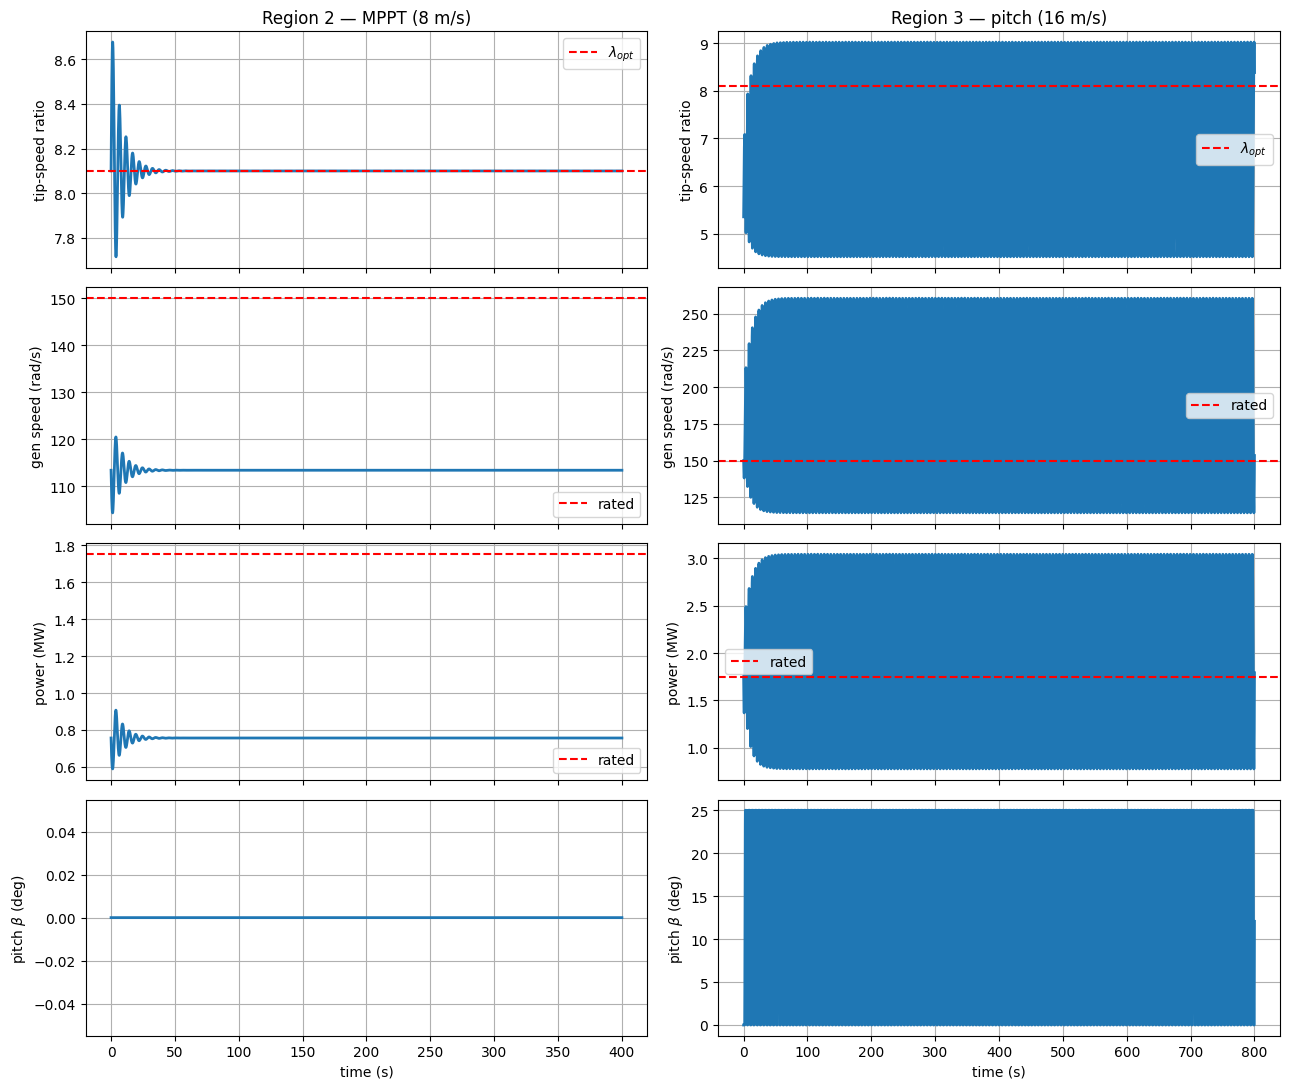

In [5]:
def unpack(res):
    t = np.asarray(res.time); vw = res.outputs["v_w"][:, 0]
    wr, wg = res.outputs["states"][:, 0], res.outputs["states"][:, 2]
    Te, be = res.outputs["T_e"][:, 0], res.outputs["beta"][:, 0]
    return t, vw, wr, wg, Te * wg / 1e6, be, wr * R / np.maximum(vw, 0.1)

fig, ax = plt.subplots(4, 2, figsize=(13, 11), sharex="col")
for col, (res, title) in enumerate([(res2, "Region 2 — MPPT (8 m/s)"),
                                     (res3, "Region 3 — pitch (16 m/s)")]):
    t, vw, wr, wg, Pmw, be, tsr = unpack(res)
    ax[0, col].plot(t, tsr, lw=2); ax[0, col].axhline(LAMBDA_OPT, color="r", ls="--", label=f"$\\lambda_{{opt}}$")
    ax[0, col].set_ylabel("tip-speed ratio"); ax[0, col].set_title(title); ax[0, col].legend()
    ax[1, col].plot(t, wg, lw=2); ax[1, col].axhline(OMEGA_G_RATED, color="r", ls="--", label="rated")
    ax[1, col].set_ylabel("gen speed (rad/s)"); ax[1, col].legend()
    ax[2, col].plot(t, Pmw, lw=2); ax[2, col].axhline(P_RATED/1e6, color="r", ls="--", label="rated")
    ax[2, col].set_ylabel("power (MW)"); ax[2, col].legend()
    ax[3, col].plot(t, be, lw=2); ax[3, col].set_ylabel("pitch $\\beta$ (deg)"); ax[3, col].set_xlabel("time (s)")
    for r in range(4): ax[r, col].grid(True)
plt.tight_layout(); plt.savefig("media/dfig_wind_turbine.png", dpi=130); plt.show()

## 5. Validation gate

The control design has two analytic targets, and we assert both on the run above:

- **Region 2 (the 8 m/s segment):** MPPT should drive the tip-speed ratio to
  $\lambda_{opt}$, i.e. the captured $C_p$ should reach $C_{p,max}$. This is *the*
  property the optimal-torque law $T_e=K_{opt}\omega_g^2$ is designed to produce.
- **Region 3 (the 16 m/s segment):** the pitch loop should hold the generator
  speed within a few percent of rated, with the blades actively pitched.

In [6]:
t2, _, wr2, _, _, beta2, tsr2 = unpack(res2)
tsr2_ss, cp2_ss, beta2_ss = tsr2[-1], cp_np(tsr2[-1]), beta2[-1]
t3, _, _, wg3, P3, beta3, _ = unpack(res3)
wg3_ss, beta3_ss, P3_ss = wg3[-1], beta3[-1], P3[-1]
print(f"Region 2 @ {t2[-1]:.0f}s:  TSR = {tsr2_ss:.3f} (opt {LAMBDA_OPT:.3f}),  "
      f"Cp = {cp2_ss:.4f} (max {CP_MAX:.4f}),  pitch = {beta2_ss:.2f} deg")
print(f"Region 3 @ {t3[-1]:.0f}s:  gen speed = {wg3_ss:.1f} rad/s (rated {OMEGA_G_RATED}),  "
      f"pitch = {beta3_ss:.1f} deg,  power = {P3_ss:.2f} MW")

assert res2.time[0] == 0.0 and res3.time[0] == 0.0,  "buffer overflow: trajectory truncated"
assert abs(tsr2_ss - LAMBDA_OPT) < 0.4,     "region 2: MPPT did not reach lambda_opt"
assert cp2_ss > 0.98 * CP_MAX,              "region 2: Cp not within 2% of Cp_max"
assert beta2_ss < 0.01,                     "region 2: pitch should be zero below rated"
assert abs(wg3_ss - OMEGA_G_RATED) / OMEGA_G_RATED < 0.05, "region 3: overspeed not regulated"
assert beta3_ss > 1.0,                      "region 3: pitch should be active above rated"
print("\nVALIDATION PASSED: MPPT tracks the aerodynamic optimum; pitch holds rated above rated wind.")

Region 2 @ 400s:  TSR = 8.100 (opt 8.100),  Cp = 0.4800 (max 0.4800),  pitch = 0.00 deg
Region 3 @ 800s:  gen speed = 153.5 rad/s (rated 150.0),  pitch = 12.1 deg,  power = 1.79 MW

VALIDATION PASSED: MPPT tracks the aerodynamic optimum; pitch holds rated above rated wind.


## 6. Diagnostics: where did the captured power go?

A quick energy-accounting check. In region 2 the captured power should equal the MPPT generator power (no pitch loss). In region 3 the aerodynamic power available far exceeds rated, and pitch deliberately throws the rest away — quantify that shed fraction so the controller's job is explicit.

In [7]:
# Region 2 capture efficiency
t2, vw2, wr2, _, P2, be2, ts2 = unpack(res2)
Pa2 = 0.5 * RHO * np.pi * R**2 * cp_np(ts2[-1], be2[-1]) * vw2[-1]**3 / 1e6
print(f"Region 2: aero power {Pa2:.2f} MW, electrical {P2[-1]:.2f} MW "
      f"-> capture efficiency {P2[-1]/Pa2*100:.1f}%")
# Region 3 shed fraction
t3, vw3, _, _, P3, _, _ = unpack(res3)
Pa3_unpitched = 0.5 * RHO * np.pi * R**2 * CP_MAX * vw3[-1]**3 / 1e6
print(f"Region 3: an unpitched rotor could capture ~{Pa3_unpitched:.1f} MW at {vw3[-1]:.0f} m/s; "
      f"pitch sheds it to hold {P3[-1]:.2f} MW ({(1-P3[-1]/Pa3_unpitched)*100:.0f}% shed).")

Region 2: aero power 0.76 MW, electrical 0.76 MW -> capture efficiency 100.0%
Region 3: an unpitched rotor could capture ~6.1 MW at 16 m/s; pitch sheds it to hold 1.79 MW (70% shed).


## 7. Failure mode: a mistuned MPPT gain leaves energy on the table

The MPPT gain $K_{opt}=\tfrac{1}{2}\rho\pi R^5 C_{p,max}/(\lambda_{opt}^3 N^3)$ is what
makes $\lambda_{opt}$ the *equilibrium* tip-speed ratio. Get it wrong (a common
field error — the air density, a tweaked blade) and the turbine settles at the
wrong $\lambda$, capturing less than $C_{p,max}$. We re-run region 2 with the gain
inflated 2x and measure the lost capture.

In [8]:
def region2_cp(k_opt_scale):
    global K_OPT
    k_save = K_OPT; K_OPT = k_save * k_opt_scale
    try:
        r = run(8.0, LAMBDA_OPT * 8.0 / R, 400.0)
        wr = r.outputs["states"][-1, 0]; vw = r.outputs["v_w"][-1, 0]
        lam = wr * R / vw; return lam, cp_np(lam)
    finally:
        K_OPT = k_save

lam_ok, cp_ok = region2_cp(1.0)
lam_bad, cp_bad = region2_cp(2.0)
print(f"correct K_OPT:  TSR {lam_ok:.2f}, Cp {cp_ok:.4f}")
print(f"2x  K_OPT:      TSR {lam_bad:.2f}, Cp {cp_bad:.4f}  "
      f"-> {(1-cp_bad/cp_ok)*100:.1f}% less energy captured at the same wind")

21:58:33.336 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


21:58:33.337 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=0.1, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=4, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 5 nodes), rtol=1e-06, atol=1e-08, max_step_size=0.1, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


21:58:33.524 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


21:58:33.524 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=0.1, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=4, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 5 nodes), rtol=1e-06, atol=1e-08, max_step_size=0.1, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


correct K_OPT:  TSR 8.10, Cp 0.4800
2x  K_OPT:      TSR 5.84, Cp 0.3594  -> 25.1% less energy captured at the same wind


## 8. Exercises
1. **Region-2.5 transition.** Add a constant-speed region between MPPT and pitch:
   above a speed threshold but below rated power, hold $\omega_g$ constant by torque
   while $\beta=0$. Where does it sit on the $C_p$ surface?
2. **Drivetrain mode.** The two-mass shaft has a torsional resonance. Estimate it
   from $K_{shaft}$ and the inertias, then excite it with a wind step and read the
   ring-down off $\theta_{tw}$.
3. **Turbulent wind.** Replace the step with a mean + band-limited noise wind
   (`jaxonomy.library` has stochastic sources) and measure how much MPPT $C_p$
   drops under unsteady inflow versus the steady optimum.
4. **Pitch rate limit.** Real pitch actuators slew at a few deg/s. Add a
   `RateLimiter` on $\beta$ and check the region-3 overspoot when wind gusts.

## 9. Key takeaways
- Variable-speed turbine control is two regimes glued together: **MPPT torque**
  below rated (sit at $\lambda_{opt}$) and **pitch regulation** above rated (hold
  rated power/speed). The handoff is automatic once the torque law saturates.
- The MPPT optimal-torque gain is not a free knob — it is fixed by the aerodynamics
  ($\lambda_{opt}$, $C_{p,max}$) and the gearbox, and getting it wrong costs energy.
- The huge rotor inertia makes both loops slow; honest plots need a `buffer_length`
  large enough to capture the full settling transient.

## References
- S. Heier, *Grid Integration of Wind Energy*, Wiley — the $C_p(\lambda,\beta)$ fit.
- J. Jonkman et al., *Definition of a 5-MW Reference Wind Turbine*, NREL/TP-500-38060
  — region 2 / region 3 control architecture.
